In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

In [ ]:
# Import All Dataset

import pickle

with open("../saved_models/cnn_train.pkl", "rb") as f:
  cnn_train = pickle.load(f)

In [33]:
print(cnn_train.shape)
print(cnn_train.keys())

(5515, 2)
Index(['img_id', 'diagnostic'], dtype='object')


In [34]:
# Get Imgs + Labels

imgs = []
labels = []

for i in range(len(cnn_train)):
  image = cv2.imread(cnn_train["img_id"][i])
  image_resize = cv2.resize(image, (224, 224))
  image_rgb = cv2.cvtColor(image_resize, cv2.COLOR_BGR2RGB)
  imgs.append(image_rgb)
  labels.append(cnn_train["diagnostic"][i])

In [46]:
print(cnn_train["img_id"][0])

flip_blur_imgs/PAT_1220_765_464.png


In [55]:
# Split The Data + Class Weight

from sklearn.model_selection import train_test_split
tempImgs = np.array(imgs)
tempLabels = np.array(labels)

x_train, x_test, y_train, y_test = train_test_split(tempImgs, tempLabels, test_size = 0.3, random_state = 42, stratify = tempLabels)

In [56]:
# Images Normalization

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [57]:
# Labels OneHotEncoding

from sklearn.preprocessing import LabelEncoder

labelEncoder = LabelEncoder()
y_train = labelEncoder.fit_transform(y_train)
y_test = labelEncoder.transform(y_test)
print(labelEncoder.classes_)

orderLabels = labelEncoder.classes_

print(labelEncoder.classes_[0])

['ACK' 'BCC' 'MEL' 'NEV' 'SCC' 'SEK']
ACK


(3860, 224, 224, 3)
(1655, 224, 224, 3)


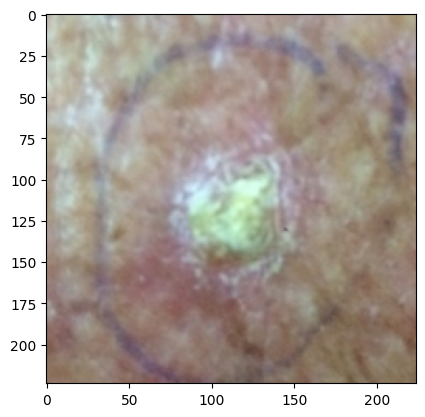

In [58]:
print(x_train.shape)
print(x_test.shape)

plt.imshow(x_train[0])

In [59]:
# Class Weights

from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
  class_weight = "balanced",
  classes = np.unique(y_train),
  y = y_train
)

class_weights_dict = dict(enumerate(class_weights))

print(class_weights_dict)
print(np.unique(y_train))

{0: np.float64(0.5200754513608192), 1: np.float64(0.45854122119268237), 2: np.float64(6.992753623188406), 3: np.float64(1.6083333333333334), 4: np.float64(1.87015503875969), 5: np.float64(1.6753472222222223)}
[0 1 2 3 4 5]


In [60]:
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

y_train = tf.keras.utils.to_categorical(y_train)
y_test = tf.keras.utils.to_categorical(y_test)

In [69]:
# Transfer Learning Model

mobileNet = MobileNet(input_shape = (224, 224, 3), include_top = False, weights = "imagenet", pooling = "max")

for layer in mobileNet.layers[:-20]:
  layer.trainable = False

for layer in mobileNet.layers[-20:]:
  layer.trainable = True

base_model = Sequential([
  mobileNet,
  layers.Dense(64, activation = "relu"),
  layers.Dropout(0.3),
  layers.Dense(64, activation = "relu", kernel_regularizer = tf.keras.regularizers.l2(0.001)),
  layers.Dropout(0.3),
  layers.Dense(32, activation = "relu", kernel_regularizer = tf.keras.regularizers.l2(0.001)),
  layers.Dense(6, activation = "softmax")])

In [ ]:
base_model.compile(optimizer = "adam", loss = "categorical_crossentropy", metrics = ["accuracy"])

checkPoint = ModelCheckpoint("../saved_models/best_cnn_model.keras", monitor = "val_accuracy", mode = "max")
earlyStopping = EarlyStopping(monitor = "val_accuracy", mode = "max", patience = 10, restore_best_weights = True)

hist = base_model.fit(x_train, y_train, epochs = 75, validation_split = 0.2, batch_size = 32, class_weight = class_weights_dict, callbacks = [checkPoint, earlyStopping])

Epoch 1/75
97/97 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.2066 - loss: 2.1910 - val_accuracy: 0.3614 - val_loss: 1.7114
Epoch 2/75
97/97 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.2788 - loss: 1.7621 - val_accuracy: 0.4482 - val_loss: 1.7137
Epoch 3/75
97/97 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.2451 - loss: 1.6471 - val_accuracy: 0.3795 - val_loss: 1.5477
Epoch 4/75
97/97 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.3151 - loss: 1.5145 - val_accuracy: 0.4819 - val_loss: 1.4262
Epoch 5/75
97/97 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.3131 - loss: 1.5106 - val_accuracy: 0.5207 - val_loss: 1.3764
Epoch 6/75
97/97 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.3504 - loss: 1.4555 - val_accuracy: 0.5104 - val_loss: 1.5875
Epoch 7/75
97/97 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.3750 - loss: 1.3984 - val_accuracy: 0.3316 - val_loss: 1.3961
Epoch 8/75
97/97 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.3193 - loss: 1.4717 - val_accuracy: 0.0946 - v

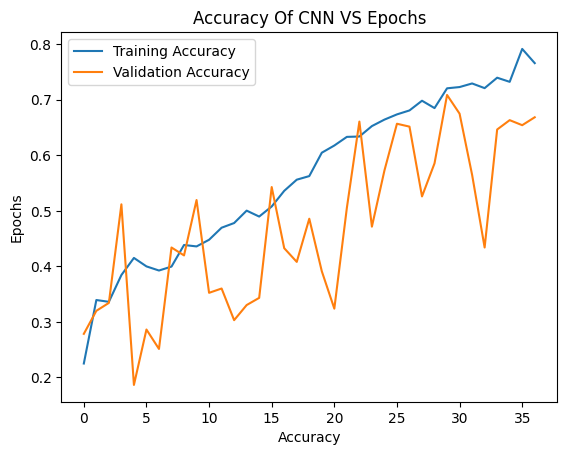

In [ ]:
# Accuracy Visualization

plt.plot(hist.history["accuracy"], label = "Training Accuracy")
plt.plot(hist.history["val_accuracy"], label = "Validation Accuracy")

plt.title("Accuracy Of CNN VS Epochs")
plt.xlabel("Accuracy")
plt.ylabel("Epochs")

plt.legend()
plt.show()

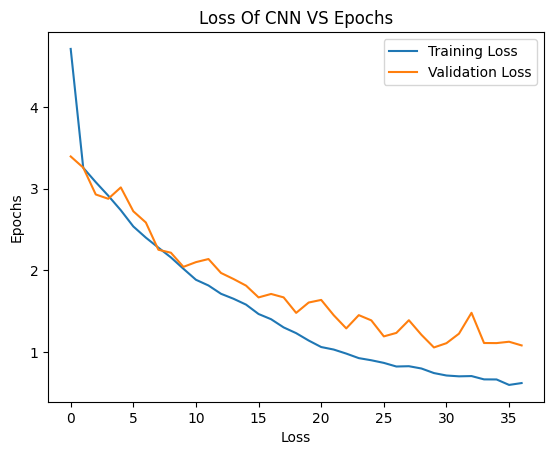

In [ ]:
# Loss Visualization

plt.plot(hist.history["loss"], label = "Training Loss")
plt.plot(hist.history["val_loss"], label = "Validation Loss")

plt.title("Loss Of CNN VS Epochs")
plt.xlabel("Loss")
plt.ylabel("Epochs")

plt.legend()
plt.show()

In [ ]:
base_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenet_1.00_224 (Functional) │ (None, 1024)           │     3,228,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,533,748 (21.11 MB)

 Trainable params: 1,118,502 (4.27 MB)

 Non-trainable params: 2,178,240 (8.31 MB)

 Optimizer params: 2,237,006 (8.53 MB)

In [ ]:
# Evaluate The model

model_loss, model_accuracy = base_model.evaluate(x_test, y_test)

print(f"Model Loss {model_loss}")
print(f"Model Accuracy {model_accuracy}")

52/52 ━━━━━━━━━━━━━━━━━━━━ 30s 567ms/step - accuracy: 0.6828 - loss: 1.0838
Model Loss 1.0837702751159668
Model Accuracy 0.6827794313430786


In [ ]:
# Save Model

base_model.save("../saved_models/cnn_tf_model.keras")

In [ ]:
# Export Label Encoder

import pickle

with open("../saved_models/labelEncoder.pkl", "wb") as f:
  pickle.dump(labelEncoder, f)

In [ ]:
# Export Labels' Dictionary, Train, Test

# import pickle

# with open("orderLabels.pkl", "wb") as f:
#   pickle.dump(orderLabels, f)

# with open("x_train_cnn.pkl", "wb") as f:
#   pickle.dump(x_train, f)

# with open("y_train_cnn.pkl", "wb") as f:
#   pickle.dump(y_train, f)

# with open("x_test_cnn.pkl", "wb") as f:
#   pickle.dump(x_test, f)

# with open("y_test_cnn.pkl", "wb") as f:
#   pickle.dump(y_test, f)